In [1]:
!gdown 1Z3bs8lnk6os1n5RE7x_p75JR-1yk1sfi

Downloading...
From: https://drive.google.com/uc?id=1Z3bs8lnk6os1n5RE7x_p75JR-1yk1sfi
To: /Users/juberry/Documents/Code/Machine-Learning/Machine Learning/Supervised_Learning/Regression/Linear Regression/advertising.zip
100%|█████████████████████████████████████| 1.90k/1.90k [00:00<00:00, 5.62MB/s]


In [2]:
!unzip advertising.zip

Archive:  advertising.zip
  inflating: advertising.csv         


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [26]:
def get_column(data, x):
    return np.take(data, indices=x, axis=1)

In [46]:
def prepare_data(file_name_dataset):
    data = np.genfromtxt(file_name_dataset, delimiter=",", skip_header=1).tolist()
    n = len(data)
    tv_data = get_column(data, 0)
    radio_data = get_column(data, 1)
    newspaper_data = get_column(data, 2)
    sale_data = get_column(data, 3)
    
    X =[tv_data, radio_data,newspaper_data]
    y = sale_data
    return X, y
X, y = prepare_data("advertising.csv")

print(X)
list = [sum(X[0][:5]), sum(X[1][:5]), sum(X[2][:5]), sum(y[:5])]
print(list)

[array([230.1,  44.5,  17.2, 151.5, 180.8,   8.7,  57.5, 120.2,   8.6,
       199.8,  66.1, 214.7,  23.8,  97.5, 204.1, 195.4,  67.8, 281.4,
        69.2, 147.3, 218.4, 237.4,  13.2, 228.3,  62.3, 262.9, 142.9,
       240.1, 248.8,  70.6, 292.9, 112.9,  97.2, 265.6,  95.7, 290.7,
       266.9,  74.7,  43.1, 228. , 202.5, 177. , 293.6, 206.9,  25.1,
       175.1,  89.7, 239.9, 227.2,  66.9, 199.8, 100.4, 216.4, 182.6,
       262.7, 198.9,   7.3, 136.2, 210.8, 210.7,  53.5, 261.3, 239.3,
       102.7, 131.1,  69. ,  31.5, 139.3, 237.4, 216.8, 199.1, 109.8,
        26.8, 129.4, 213.4,  16.9,  27.5, 120.5,   5.4, 116. ,  76.4,
       239.8,  75.3,  68.4, 213.5, 193.2,  76.3, 110.7,  88.3, 109.8,
       134.3,  28.6, 217.7, 250.9, 107.4, 163.3, 197.6, 184.9, 289.7,
       135.2, 222.4, 296.4, 280.2, 187.9, 238.2, 137.9,  25. ,  90.4,
        13.1, 255.4, 225.8, 241.7, 175.7, 209.6,  78.2,  75.1, 139.2,
        76.4, 125.7,  19.4, 141.3,  18.8, 224. , 123.1, 229.5,  87.2,
         7.8,  80.2

In [41]:
def initialize_params():
    w1 = random.gauss(mu=0.0, sigma=0.01)
    w2 = random.gauss(mu=0.0, sigma=0.01)
    w3 = random.gauss(mu=0.0, sigma=0.01)
    b = 0

    #w1, w2, w3, b = (0.016992259082509283, 0.0070783670518262355, -0.002307860847821344, 0)
    return w1, w2, w3, b

In [42]:
def predict(x1, x2, x3, w1, w2, w3, b):
    res = x1*w1 + x2*w2 + x3*w3 + b
    return res
y = predict(x1=1, x2=1, x3=1, w1=0, w2=0.5, w3=0, b=0.5)
print(y)

1.0


In [43]:
def compute_loss(y_hat, y):
    return (y_hat - y) * (y_hat - y)
l = compute_loss(y_hat=1, y=0.5)
print(l)

0.25


In [44]:
def compute_gradient_wi(xi, y, y_hat):
    return 2*xi*(y_hat-y)
def compute_gradient_b(y, y_hat):
    return 2*(y_hat-y)

g_wi = compute_gradient_wi(xi=1.0, y=1.0, y_hat=0.5)
print(g_wi)
g_b = compute_gradient_b(y=2.0, y_hat=0.5)
print(g_b)

-1.0
-3.0


In [45]:
def update_weight_wi(wi, dl_dwi, lr):
    wi = wi - lr * (dl_dwi)
    return wi
def update_weight_b(b, dl_db, lr):
    b = b - lr * (dl_db)
    return b

after_wi = update_weight_wi(wi=1.0, dl_dwi=-0.5, lr=1e-5)
print(after_wi)
after_b = update_weight_b(b=0.5, dl_db=-1.0, lr=1e-5)
print(after_b)

1.000005
0.50001


In [57]:
history = []
def implement_linear_regression(X_data, y_data, epoch_max = 50, lr = 1e-5):
    losses = []    
    w1, w2, w3, b = initialize_params()
    N = len(y_data)
    for epoch in range(epoch_max):
        for i in range (N):
            x1 = X_data[0][i]
            x2 = X_data[1][i]
            x3 = X_data[2][i]
            
            y = y_data[i]
            
            y_hat = predict(x1, x2, x3, w1, w2, w3, b)
            
            loss = compute_loss(y_hat, y)
            
            dl_dw1 = compute_gradient_wi(x1, y, y_hat)
            dl_dw2 = compute_gradient_wi(x2, y, y_hat)
            dl_dw3 = compute_gradient_wi(x3, y, y_hat)
            dl_db = compute_gradient_b(y, y_hat)
            
            w1 = update_weight_wi(w1, dl_dw1, lr)
            w2 = update_weight_wi(w2, dl_dw2, lr)
            w3 = update_weight_wi(w3, dl_dw3, lr)
            b = update_weight_b(b, dl_db, lr)
            
            losses.append(loss)
            history.append((w1, w2, w3, b))
    return (w1, w2, w3, b, losses)

841
0.07405990204350121 0.15917376082537923 0.017561268719476854
[np.float64(410.1125423408413), np.float64(14.416499354271915), np.float64(47.36189941464952), np.float64(10.519754701225976), np.float64(3.6961952637800444), np.float64(5.8225230680955296), np.float64(22.268169185430448), np.float64(0.4074598353999619), np.float64(14.865624628968394), np.float64(22.625405171452325), np.float64(39.7345717000009), np.float64(4.790338009952383), np.float64(11.762318662020482), np.float64(29.317292478614913), np.float64(6.796520933514934), np.float64(8.850936041158384), np.float64(0.1926181552154699), np.float64(24.44440931575634), np.float64(30.927263284782317), np.float64(7.047719879920614), np.float64(5.263803588475159), np.float64(0.1272803692356678), np.float64(4.152583607999954), np.float64(8.072884897274347), np.float64(10.532257220909576), np.float64(46.2293915751461), np.float64(36.51693895062351), np.float64(7.877065378971565), np.float64(13.229417836153049), np.float64(12.44868746

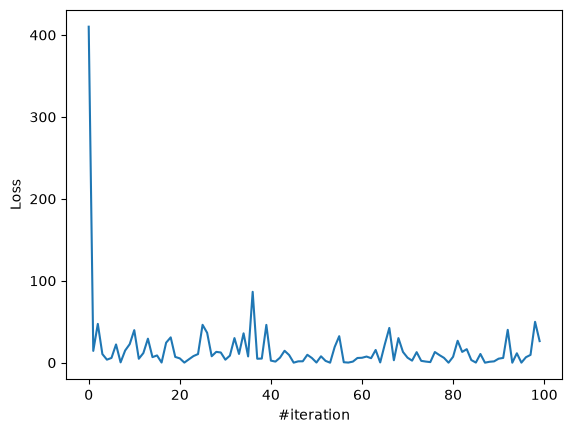

In [72]:
print(np.argmin(losses))
(w1,w2,w3,b, losses) = implement_linear_regression(X,y)
print(w1, w2, w3)
print(losses[0:100])
plt.plot(losses[0:100])
plt.xlabel("#iteration")
plt.ylabel("Loss")
plt.show()

In [54]:
tv = 19.2
radio = 35.9
newspaper = 51.3

(w1, w2, w3, b, losses) = implement_linear_regression(X, y,epoch_max=50, lr=1e-5)
sales = predict(tv, radio, newspaper, w1, w2, w3, b)
print(f"predicted sales is {sales:.2f}")

predicted sales is 8.18


6.2766151170085295e-06


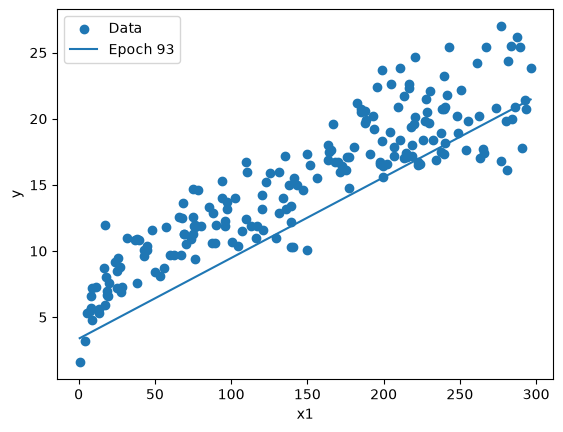

In [73]:
x1 = np.array(X[0])
y = np.array(y)

x1_plot = np.linspace(x1.min(), x1.max(), 100)

x2_mean = np.mean(X[1])
x3_mean = np.mean(X[2])

plt.scatter(x1, y, label="Data")

epochs_to_print = {93}
print(losses[93])

for epoch, (w1, w2, w3, b) in enumerate(history):

    current_epoch = epoch + 1

    if current_epoch in epochs_to_print:

        y_plot = (
            w1 * x1_plot
            + w2 * x2_mean
            + w3 * x3_mean
            + b
        )

        plt.plot(
            x1_plot,
            y_plot,
            label=f"Epoch {current_epoch}"
        )

plt.xlabel("x1")
plt.ylabel("y")
plt.legend()
plt.show()